<a href="https://colab.research.google.com/github/sunilsinghuk/Python-Programming/blob/main/Lecture_5_6_Grouping%20and%20Aggregating%20Data%20and%20Pivot%20Table%20Creation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lecture 5: Grouping and Aggregating Data and Pivot Table Creation**
## **1. Introduction to Grouping Data**
1. Grouping data is useful for summarizing and analyzing large datasets.
2. The groupby() function in Pandas allows us to split data into groups based on a column's values.
3. It is often used in combination with aggregation functions to derive insights.

## **2. Using groupby() to Group Data**
- The groupby() method groups data based on specified columns.

In [ ]:
#df.groupby('column_name')

In [ ]:
import pandas as pd

data = {
    'Department': ['HR', 'IT', 'IT', 'HR', 'Finance', 'Finance', 'IT'],
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace'],
    'Salary': [50000, 70000, 80000, 55000, 60000, 62000, 75000]
}

df = pd.DataFrame(data)
print(df)
grouped = df.groupby('Department')
print(grouped.first())  # Displays the first employee in each department


  Department Employee  Salary
0         HR    Alice   50000
1         IT      Bob   70000
2         IT  Charlie   80000
3         HR    David   55000
4    Finance      Eve   60000
5    Finance    Frank   62000
6         IT    Grace   75000
           Employee  Salary
Department                 
Finance         Eve   60000
HR            Alice   50000
IT              Bob   70000


## **3. Iterating Over Groups**
- We can iterate over groupby() objects to access each group separately.

In [ ]:
for name, group in df.groupby('Department'):
    print(f"\nDepartment: {name}")
    print(group)


Department: Finance
  Department Employee  Salary
4    Finance      Eve   60000
5    Finance    Frank   62000

Department: HR
  Department Employee  Salary
0         HR    Alice   50000
3         HR    David   55000

Department: IT
  Department Employee  Salary
1         IT      Bob   70000
2         IT  Charlie   80000
6         IT    Grace   75000


## **4. Aggregating Data**
Aggregation functions allow us to compute summary statistics for grouped data.

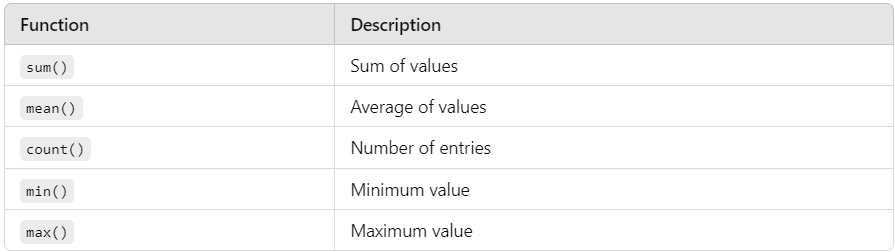

**Applying Aggregation Functions**


In [ ]:
# Calculate the average salary per department
average_salary = df.groupby('Department')['Salary'].mean()
print(average_salary)

Department
Finance    61000.0
HR         52500.0
IT         75000.0
Name: Salary, dtype: float64


**Custom Aggregation using apply()**

**apply()** allows us to define our own aggregation functions.

In [ ]:
def salary_range(x):
    return x.max() - x.min()

salary_diff = df.groupby('Department')['Salary'].apply(salary_range)
print(salary_diff)


Department
Finance     2000
HR          5000
IT         10000
Name: Salary, dtype: int64


# **Lecture 6: Pivot Tables and Cross-Tabulations**
## **1. Introduction to Pivot Tables**
Pivot tables help reorganize and summarize data in a structured format.
The pivot_table() function is used for this purpose.

## **2. Creating Pivot Tables**


In [ ]:
#df.pivot_table(index='column1', columns='column2', values='column3',aggfunc='function')

**Example:**

In [ ]:
data = {
    'Department': ['HR', 'IT', 'IT', 'HR', 'Finance', 'Finance', 'IT'],
    'Gender': ['F', 'M', 'M', 'M', 'F', 'M', 'F'],
    'Salary': [50000, 70000, 80000, 55000, 60000, 62000, 75000]
}

df = pd.DataFrame(data)

pivot = df.pivot_table(index='Department', columns='Gender', values='Salary', aggfunc='mean')
print(pivot)

Gender            F        M
Department                  
Finance     60000.0  62000.0
HR          50000.0  55000.0
IT          75000.0  75000.0


## **3. Customizing Pivot Tables**
We can add totals using the **margins=True** argument.


In [ ]:
pivot = df.pivot_table(index='Department', columns='Gender', values='Salary', aggfunc='mean', margins=True)
print(pivot)

Gender                 F        M           All
Department                                     
Finance     60000.000000  62000.0  61000.000000
HR          50000.000000  55000.0  52500.000000
IT          75000.000000  75000.0  75000.000000
All         61666.666667  66750.0  64571.428571


## **4. Cross-Tabulations**
**crosstab()** is useful for frequency tables.
- Cross-tabulation (cross-tab) is a method to summarize categorical data by counting occurrences in a tabular format. It helps in analyzing relationships between two categorical variables.

**Syntax:**



In [ ]:
#pd.crosstab(df['column1'], df['column2'])

In [ ]:
crosstab_result = pd.crosstab(df['Department'], df['Gender'])
print(crosstab_result)
print(df)

Gender      F  M
Department      
Finance     1  1
HR          1  1
IT          1  2
  Department Gender  Salary
0         HR      F   50000
1         IT      M   70000
2         IT      M   80000
3         HR      M   55000
4    Finance      F   60000
5    Finance      M   62000
6         IT      F   75000


## **5. Hands-on Practice**
Use a real dataset and apply **groupby(), pivot_table(), and crosstab()** to analyze data.
